# Statlig samferdselsfinansiering: bevilgningsår-analyse 2005–2039

Analyse basert på kombinert datasett fra `Prosjekter_SVV_2005-2026` og `Prosjekter_2014_2026pluss`.

**Forskjell fra tidligere analyser:** I stedet for å fordele statlige kostnader til *ferdigstillelsesår*, fordeles de jevnt over *anleggsperioden* (vedtaksår + 1 → ferdigstillelse). Dette gir et mer rettferdig bilde av når pengene faktisk brukes, og er direkte sammenlignbart med Gillesviks tall som ser på årlig statsbudsjettbevilgning.

**Datakilder:**
- `Prosjekter_SVV_2005-2026`: SVV-prosjekter 2005-2039
- `Prosjekter_2014_2026pluss`: Alle virksomheter 2014-2039 (inkl Hordfast/Møreaksen placeholder)

**Metode:**
- Lineær fordeling av statlig andel over anleggsperioden
- Anleggsperiode estimert fra "Lagt fram for Stortinget" + 1 år til trafikkåpning
- Manuelle anleggsperioder for kjente megaprosjekter (Rogfast, Arna-Stanghelle, Sotrasambandet osv.)
- ERTMS fordeles på alle landsdeler etter befolkningsandel

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import re

plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False, 'axes.spines.right': False,
    'figure.dpi': 110, 'axes.grid': True,
    'grid.alpha': 0.25, 'axes.axisbelow': True,
})

FARGER = {'OST':'#185FA5','VEST':'#D85A30','NORD':'#0F6E56','MIDT':'#7F77DD','SOR':'#888780'}
FARGER = {'ØST':'#185FA5','VEST':'#D85A30','NORD':'#0F6E56','MIDT':'#7F77DD','SØR':'#888780'}
RNAVN = {'ØST':'Østlandet','VEST':'Vestlandet','NORD':'Nord-Norge','MIDT':'Trøndelag','SØR':'Sørlandet'}
FOLK = {'ØST':2_870_000,'VEST':1_420_000,'NORD':480_000,'MIDT':480_000,'SØR':320_000}
TOTAL_FOLK = sum(FOLK.values())
BEF = {ld: FOLK[ld]/TOTAL_FOLK*100 for ld in FOLK}
REGIONS = ['ØST','VEST','NORD','MIDT','SØR']

## 1. Last og kombiner data

In [4]:
XLSX = 'Samferdselprosjekter_pr_landsdel_over_tid_public.xlsx'

df_pluss = pd.read_excel(XLSX, sheet_name='Prosjekter_2014_2026pluss', header=4)
df_pluss = df_pluss.dropna(subset=['navn']).copy()

df_svv = pd.read_excel(XLSX, sheet_name='Prosjekter_SVV_2005-2026', header=4)
df_svv = df_svv.dropna(subset=['Prosjekt']).copy()
df_svv['aar_ferdig'] = pd.to_numeric(df_svv['Trafikkåpning_bruk'], errors='coerce')
df_svv['vedtak'] = pd.to_numeric(df_svv['Lagt fram for Stortinget (år)'], errors='coerce')
df_svv['stat'] = pd.to_numeric(df_svv['Kostnad stat 2026kr'], errors='coerce').fillna(0)
df_svv['total'] = pd.to_numeric(df_svv['Prognose/endelig sluttkostnad (indeksert)'], errors='coerce').fillna(0)
df_svv['andel'] = pd.to_numeric(df_svv['Statlig andel (sjekket)'], errors='coerce').fillna(0)

def norm(s):
    if pd.isna(s): return ''
    s = str(s).lower()
    s = re.sub(r'[–—\-/,()]', ' ', s)
    s = re.sub(r'\s+', ' ', s).replace('rv.', 'rv').replace('fv.', 'fv')
    return ' '.join(s.split()[:3])

df_svv['key'] = df_svv['Prosjekt'].apply(norm)
svv_lookup = {}
for _, r in df_svv.iterrows():
    svv_lookup[r['key']] = {
        'vedtak': r['vedtak'], 'fylke': r['Fylke'],
        'total': r['total'], 'andel': r['andel']
    }

# Bygg kombinert datasett
rows = []
for _, r in df_pluss.iterrows():
    key = norm(r['navn'])
    sv = svv_lookup.get(key, {})
    rows.append({
        'virksomhet': r['virksomhet'], 'status': r['status'],
        'navn': r['navn'], 'landsdel': r['landsdel'],
        'fylke': sv.get('fylke'),
        'vedtak_aar': sv.get('vedtak'),
        'aar_ferdig': r['aar_ferdig'],
        'total_2026kr': sv.get('total') if sv.get('total', 0) > 0 else None,
        'statlig_andel': sv.get('andel'),
        'statlig_2026kr': r['stat_korrigert_2026'],
        'kilde': 'pluss', 'kommentar': r.get('kommentar')
    })

svv_pre_2014 = df_svv[(df_svv['aar_ferdig'] >= 2005) & (df_svv['aar_ferdig'] <= 2013)]
for _, r in svv_pre_2014.iterrows():
    rows.append({
        'virksomhet': 'SVV', 'status': 'Ferdig',
        'navn': r['Prosjekt'], 'landsdel': r['Landsdel'],
        'fylke': r['Fylke'],
        'vedtak_aar': r['vedtak'], 'aar_ferdig': r['aar_ferdig'],
        'total_2026kr': r['total'] if r['total'] > 0 else None,
        'statlig_andel': r['andel'], 'statlig_2026kr': r['stat'],
        'kilde': 'svv_pre2014', 'kommentar': r.get('Kommentar')
    })

df = pd.DataFrame(rows)
df['aar_ferdig'] = pd.to_numeric(df['aar_ferdig'], errors='coerce')
df['vedtak_aar'] = pd.to_numeric(df['vedtak_aar'], errors='coerce')
df['statlig_2026kr'] = pd.to_numeric(df['statlig_2026kr'], errors='coerce').fillna(0)

print(f'Totalt prosjekter: {len(df)}')
print(f'Per virksomhet:')
print(df['virksomhet'].value_counts())

Totalt prosjekter: 123
Per virksomhet:
virksomhet
SVV       96
BANE      17
NV         8
AVINOR     2
Name: count, dtype: int64


## 2. Estimer oppstartsår

Manuelle vedtaksår for BANE/NV/AVINOR (basert på Stortingsproposisjoner) og spesifikke anleggsperioder for kjente megaprosjekter.

In [5]:
MANUAL_VEDTAK = {
    'Dobbeltspor Langset–Kleverud': 2011, 'Holm–Holmestrand–Nykirke': 2009,
    'Dobbeltspor Farriseidet–Porsgrunn': 2009, 'Follobanen': 2013,
    'Venjar–Eidsvoll–Langset': 2017, 'Arna–Fløen': 2009,
    'Fløen–Bergen/Nygårdstangen': 2014, 'Delelektrifisering Trønder- og Meråkerbanen': 2019,
    'Drammen–Kobbervikdalen': 2018, 'ERTMS': 2018, 'Kolbotn stasjon': 2018,
    'Sandbukta–Moss–Såstad': 2014, 'Kleverud–Sørli': 2018, 'Sørli–Åkersvika': 2019,
    'Barkåker–Tønsberg': 2018, 'Nykirke–Barkåker': 2018,
    'E18 Tvedestrand–Arendal': 2016, 'E6 Kolomoen–Moelv': 2016,
    'E6 Kvænangsfjellet': 2019, 'E18 Langangen–Bamble': 2021,
    'E39 Kristiansand vest–Lyngdal vest': 2018, 'E6 Moelv–Øyer': 2018,
    'E6 Nedgård (Ulsberg)–Melhus': 2018, 'E6 Ranheim–Åsen': 2018,
    'Ny lufthavn ved Mo i Rana': 2017, 'Flytting av Bodø lufthavn': 2018,
    'E39 Hordfast': 2025, 'E39 Møreaksen': 2025,
    'E6 Nidelv bru-Grillstad (parsell på E6 Værnes-Trondheim)': 2009,
}

MANUAL_ANLEGG = {
    'E39 Rogfast': 15, 'Fellesprosjektet Vossebanen/E16 Arna–Stanghelle (vei)': 10,
    'Fellesprosjektet Vossebanen/E16 Arna–Stanghelle (bane)': 10,
    'Rv. 555 Sotrasambandet (OPS)': 5, 'Follobanen': 9,
    'Sandbukta–Moss–Såstad': 11, 'E39 Hordfast': 10, 'E39 Møreaksen': 10,
    'E134 Røldal - Seljestad': 6, 'E39 Svegatjørn-Rådal': 7,
    'E16 Lærdalstunnelen': 4, 'Holm–Holmestrand–Nykirke': 6,
    'Dobbeltspor Farriseidet–Porsgrunn': 6, 'Drammen–Kobbervikdalen': 6,
    'Ny lufthavn ved Mo i Rana': 4, 'Flytting av Bodø lufthavn': 5,
}

def default_anlegg(total, virksomhet):
    if pd.isna(total) or total <= 0:
        return {'SVV':4,'NV':4,'BANE':6,'AVINOR':5}.get(virksomhet, 4)
    if total < 1000: return 3
    if total < 3000: return 4
    if total < 7000: return 5
    if total < 15000: return 7
    if total < 30000: return 9
    return 12

df['vedtak_aar'] = df.apply(
    lambda r: MANUAL_VEDTAK.get(r['navn'], r['vedtak_aar']), axis=1)

def beregn_oppstart(row):
    ferdig = row['aar_ferdig']
    if pd.isna(ferdig): return None
    if row['navn'] in MANUAL_ANLEGG:
        return int(ferdig - MANUAL_ANLEGG[row['navn']])
    vedtak = row['vedtak_aar']
    if pd.notna(vedtak):
        oppstart = int(vedtak) + 1
        if ferdig - oppstart > 12: oppstart = int(ferdig - 10)
        if ferdig - oppstart < 2: oppstart = int(ferdig - 2)
        return oppstart
    return int(ferdig - default_anlegg(row['total_2026kr'], row['virksomhet']))

df['oppstart_aar'] = df.apply(beregn_oppstart, axis=1)
df['anleggsperiode'] = df['aar_ferdig'] - df['oppstart_aar']

print(f'Prosjekter med oppstart: {df["oppstart_aar"].notna().sum()} / {len(df)}')
print()
print('Lengste anleggsperioder:')
df.nlargest(10, 'anleggsperiode')[['navn','vedtak_aar','oppstart_aar','aar_ferdig','anleggsperiode','statlig_2026kr']]

Prosjekter med oppstart: 123 / 123

Lengste anleggsperioder:


,navn,vedtak_aar,oppstart_aar,aar_ferdig,anleggsperiode,statlig_2026kr
74,E39 Rogfast,2017.0,2018,2033,15,11334.00
83,E39 Kristiansand vest–Lyngdal vest,2018.0,2019,2031,12,22290.00
86,E6 Ranheim–Åsen,2018.0,2019,2031,12,9729.00
85,E6 Nedgård (Ulsberg)–Melhus,2018.0,2019,2030,11,14982.00
99,Sandbukta–Moss–Såstad,2014.0,2019,2030,11,35648.75
76,Fellesprosjektet Vossebanen/E16 Arna–Stanghell...,2025.0,2029,2039,10,18134.00
77,E39 Hordfast,2025.0,2029,2039,10,62000.00
78,E39 Møreaksen,2025.0,2029,2039,10,22300.00
92,Arna–Fløen,2009.0,2014,2024,10,5930.00
96,ERTMS,2018.0,2024,2034,10,47775.00


## 3. Bevilgningsår-fordeling (lineær)

Hvert prosjekt fordeles jevnt over anleggsperioden. ERTMS (HELE_LANDET) fordeles etter befolkningsandel.

In [6]:
def fordel_per_aar(prosjekt):
    if pd.isna(prosjekt['oppstart_aar']) or pd.isna(prosjekt['aar_ferdig']):
        return {}
    s, e = int(prosjekt['oppstart_aar']), int(prosjekt['aar_ferdig'])
    aar_liste = list(range(s, e + 1))
    n = len(aar_liste)
    if n == 0: return {}
    return {a: prosjekt['statlig_2026kr'] / n for a in aar_liste}

aarlig = {r: {} for r in REGIONS}
for _, p in df.iterrows():
    if p['statlig_2026kr'] <= 0: continue
    fordel = fordel_per_aar(p)
    for aar_p, belop in fordel.items():
        if p['landsdel'] == 'HELE_LANDET':
            for r in REGIONS:
                aarlig[r][aar_p] = aarlig[r].get(aar_p, 0) + belop * FOLK[r] / TOTAL_FOLK
        elif p['landsdel'] in REGIONS:
            aarlig[p['landsdel']][aar_p] = aarlig[p['landsdel']].get(aar_p, 0) + belop

aarlig_df = pd.DataFrame(aarlig).fillna(0).sort_index()
aarlig_df['TOTAL'] = aarlig_df[REGIONS].sum(axis=1)
aarlig_df = aarlig_df.loc[2010:2039]
aarlig_df.round(0).head(20)

,ØST,VEST,NORD,MIDT,SØR,TOTAL
2010,3788.0,528.0,77.0,220.0,0.0,4613.0
2011,4499.0,1074.0,663.0,220.0,0.0,6455.0
2012,9575.0,1599.0,1035.0,220.0,0.0,12429.0
2013,10703.0,2408.0,1739.0,178.0,0.0,15028.0
2014,16759.0,3230.0,1899.0,178.0,0.0,22067.0
2015,16052.0,3523.0,3074.0,0.0,0.0,22649.0
2016,13691.0,3058.0,3759.0,357.0,0.0,20866.0
2017,13579.0,3409.0,3688.0,357.0,2361.0,23394.0
2018,13684.0,3952.0,2786.0,765.0,2361.0,23548.0
2019,22187.0,4535.0,2240.0,2762.0,4076.0,35800.0


## 4. Stablet søylediagram: statlig per bevilgningsår

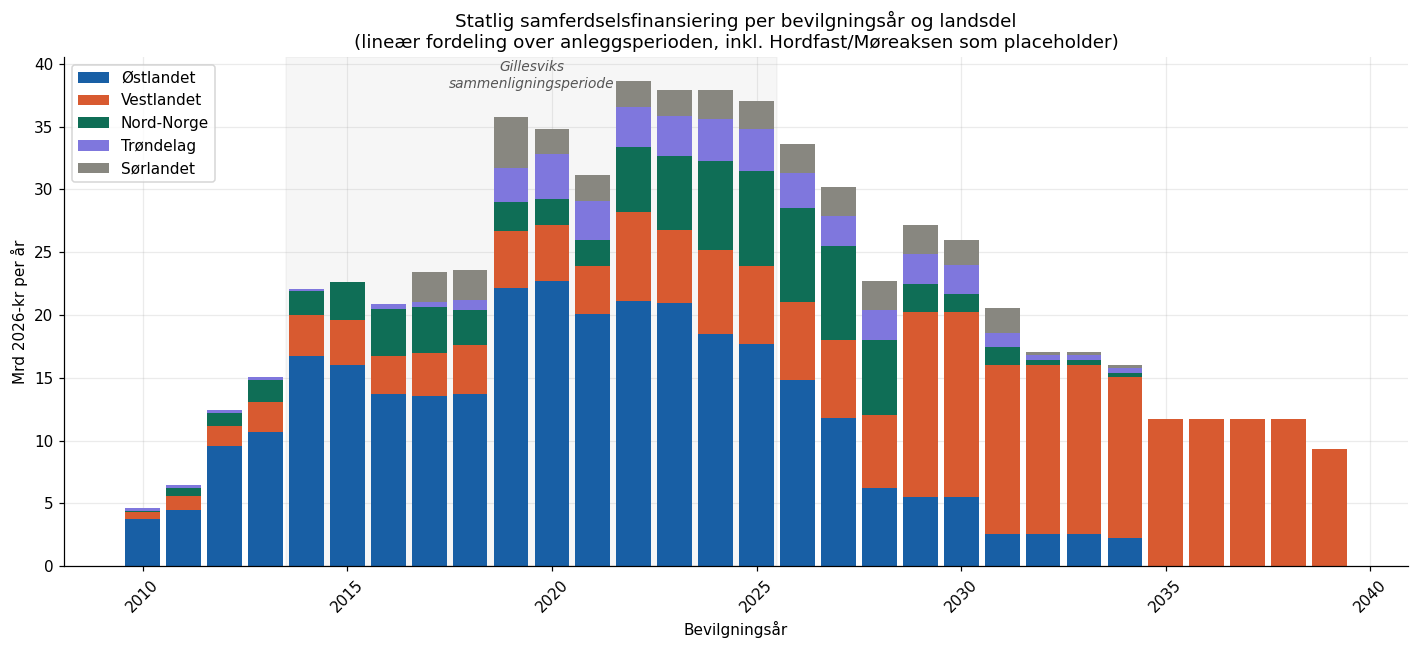

In [7]:
fig, ax = plt.subplots(figsize=(13, 6))

bottom = np.zeros(len(aarlig_df))
x = aarlig_df.index

for ld in REGIONS:
    vals = aarlig_df[ld].values / 1000
    ax.bar(x, vals, bottom=bottom, label=RNAVN[ld], color=FARGER[ld], width=0.85)
    bottom += vals

ax.set_ylabel('Mrd 2026-kr per år')
ax.set_xlabel('Bevilgningsår')
ax.set_title('Statlig samferdselsfinansiering per bevilgningsår og landsdel\n(lineær fordeling over anleggsperioden, inkl. Hordfast/Møreaksen som placeholder)',
             fontsize=12, fontweight='500')
ax.legend(loc='upper left', fontsize=10)
ax.axvspan(2013.5, 2025.5, alpha=0.07, color='gray', zorder=0)
ax.text(2019.5, ax.get_ylim()[1]*0.94, 'Gillesviks\nsammenligningsperiode',
        ha='center', fontsize=9, color='#555', style='italic')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 5. Sammenligning med Gillesviks tall (2014-2025)

In [8]:
print('='*75)
print('STATLIG FINANSIERING 2014-2025 (bevilgningsår, lineær fordeling)')
print('='*75)
print()
sum_14_25 = {ld: aarlig_df.loc[2014:2025, ld].sum() for ld in REGIONS}
total_14_25 = sum(sum_14_25.values())

print(f'{"Landsdel":<13} {"Mrd":>9} {"Andel":>8} {"Bef%":>7} {"Avvik (pp)":>12}')
print('-'*55)
for ld in REGIONS:
    andel = sum_14_25[ld]/total_14_25*100
    avvik = andel - BEF[ld]
    print(f'{RNAVN[ld]:<13} {sum_14_25[ld]/1000:>7.1f}m {andel:>6.1f}% {BEF[ld]:>6.1f}% {avvik:>+10.1f}')
print('-'*55)
print(f'{"TOTAL":<13} {total_14_25/1000:>7.1f}m')

print()
print('Gillesviks tall (sammenligning):')
print('  ØST 145 mrd (Intercity 103) = 61,2%')
print('  VEST 17 mrd SVV + 12 mrd NV = 29 mrd = 14,4%')

STATLIG FINANSIERING 2014-2025 (bevilgningsår, lineær fordeling)

Landsdel            Mrd    Andel    Bef%   Avvik (pp)
-------------------------------------------------------
Østlandet       217.0m   59.3%   51.5%       +7.8
Vestlandet       55.9m   15.3%   25.5%      -10.2
Nord-Norge       47.2m   12.9%    8.6%       +4.3
Trøndelag        24.2m    6.6%    8.6%       -2.0
Sørlandet        21.5m    5.9%    5.7%       +0.1
-------------------------------------------------------
TOTAL           365.7m

Gillesviks tall (sammenligning):
  ØST 145 mrd (Intercity 103) = 61,2%
  VEST 17 mrd SVV + 12 mrd NV = 29 mrd = 14,4%


## 6. Vestlandets andel over tid

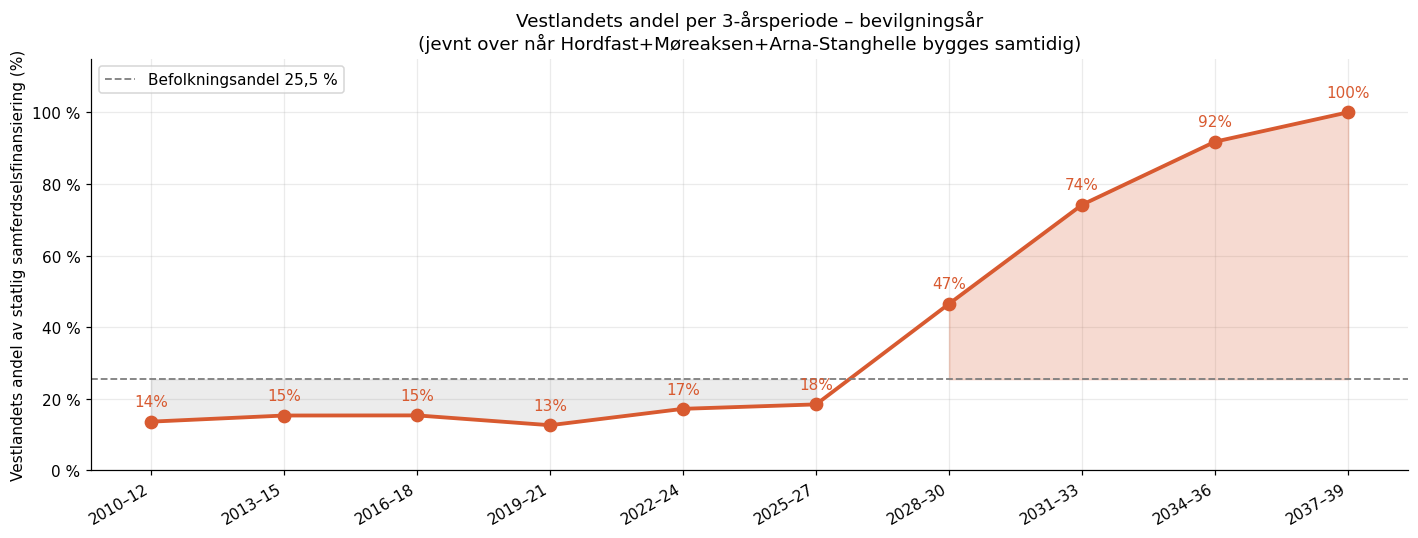

In [9]:
perioder = [(2010,2012),(2013,2015),(2016,2018),(2019,2021),
            (2022,2024),(2025,2027),(2028,2030),(2031,2033),(2034,2036),(2037,2039)]
labels = [f'{s}–{str(e)[-2:]}' for s,e in perioder]
vest_pcts = []
for s, e in perioder:
    sub = aarlig_df.loc[s:e]
    tot = sub[REGIONS].sum().sum()
    vest = sub['VEST'].sum()
    vest_pcts.append(vest/tot*100 if tot > 0 else 0)

fig, ax = plt.subplots(figsize=(13, 5))
ax.fill_between(range(len(perioder)), vest_pcts, BEF['VEST'],
                where=[v > BEF['VEST'] for v in vest_pcts],
                alpha=0.22, color=FARGER['VEST'])
ax.fill_between(range(len(perioder)), vest_pcts, BEF['VEST'],
                where=[v <= BEF['VEST'] for v in vest_pcts],
                alpha=0.15, color='gray')
ax.plot(range(len(perioder)), vest_pcts, 'o-', color=FARGER['VEST'], lw=2.5, ms=8)
ax.axhline(BEF['VEST'], color='gray', lw=1.2, ls='--',
           label=f'Befolkningsandel {BEF[chr(34)+chr(0x56)+chr(0x45)+chr(0x53)+chr(0x54)+chr(34)]:.1f} %' if False else f'Befolkningsandel 25,5 %')

for i, v in enumerate(vest_pcts):
    ax.annotate(f'{v:.0f}%', xy=(i,v), xytext=(0,10), textcoords='offset points',
                ha='center', fontsize=10, color=FARGER['VEST'])

ax.set_xticks(range(len(perioder)))
ax.set_xticklabels(labels, rotation=30, ha='right')
ax.set_ylabel('Vestlandets andel av statlig samferdselsfinansiering (%)')
ax.set_title('Vestlandets andel per 3-årsperiode – bevilgningsår\n(jevnt over når Hordfast+Møreaksen+Arna-Stanghelle bygges samtidig)',
             fontsize=12, fontweight='500')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{int(v)} %'))
ax.legend(fontsize=10)
ax.set_ylim(0, max(vest_pcts)*1.15)
plt.tight_layout()
plt.show()

## 7. Effekt av Hordfast/Møreaksen

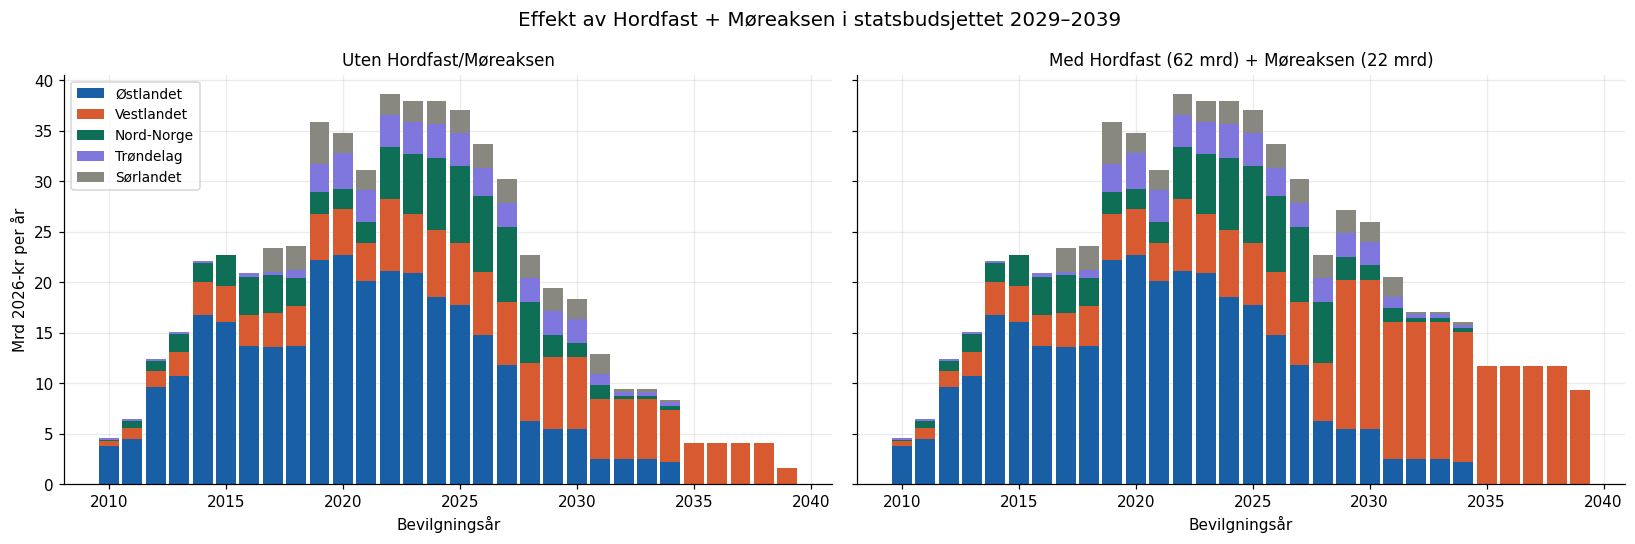


Vestlandets årlige snitt 2029–2039:
  Uten H/M:  5.0 mrd/år
  Med H/M:   12.6 mrd/år
  Differanse: +7.7 mrd/år


In [10]:
df_no_hm = df[~df['navn'].isin(['E39 Hordfast', 'E39 Møreaksen'])].copy()

aarlig_no_hm = {r: {} for r in REGIONS}
for _, p in df_no_hm.iterrows():
    if p['statlig_2026kr'] <= 0: continue
    fordel = fordel_per_aar(p)
    for aar_p, belop in fordel.items():
        if p['landsdel'] == 'HELE_LANDET':
            for r in REGIONS:
                aarlig_no_hm[r][aar_p] = aarlig_no_hm[r].get(aar_p, 0) + belop*FOLK[r]/TOTAL_FOLK
        elif p['landsdel'] in REGIONS:
            aarlig_no_hm[p['landsdel']][aar_p] = aarlig_no_hm[p['landsdel']].get(aar_p, 0) + belop

aarlig_no_hm_df = pd.DataFrame(aarlig_no_hm).fillna(0).sort_index().loc[2010:2039]

fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=True)

ymax = 0
for ax, data, tittel in zip(axes,
                             [aarlig_no_hm_df, aarlig_df.loc[2010:2039]],
                             ['Uten Hordfast/Møreaksen',
                              'Med Hordfast (62 mrd) + Møreaksen (22 mrd)']):
    bottom = np.zeros(len(data))
    for ld in REGIONS:
        vals = data[ld].values / 1000
        ax.bar(data.index, vals, bottom=bottom, color=FARGER[ld], width=0.85,
               label=RNAVN[ld] if ax==axes[0] else None)
        bottom += vals
    ymax = max(ymax, bottom.max())
    ax.set_title(tittel, fontsize=11, fontweight='500')
    ax.set_xlabel('Bevilgningsår')

for ax in axes:
    ax.set_ylim(0, ymax*1.05)
axes[0].set_ylabel('Mrd 2026-kr per år')
axes[0].legend(loc='upper left', fontsize=9)
plt.suptitle('Effekt av Hordfast + Møreaksen i statsbudsjettet 2029–2039',
             fontsize=13, fontweight='500')
plt.tight_layout()
plt.show()

print()
print(f'Vestlandets årlige snitt 2029–2039:')
print(f'  Uten H/M:  {aarlig_no_hm_df.loc[2029:2039, "VEST"].mean()/1000:.1f} mrd/år')
print(f'  Med H/M:   {aarlig_df.loc[2029:2039, "VEST"].mean()/1000:.1f} mrd/år')
diff = (aarlig_df.loc[2029:2039,'VEST']-aarlig_no_hm_df.loc[2029:2039,'VEST']).mean()
print(f'  Differanse: +{diff/1000:.1f} mrd/år')

## 8. Eksporter datasett

Begge tabeller (prosjektliste og bevilgning per år) kan brukes videre.

In [11]:
df_out = df[['virksomhet','status','navn','landsdel','fylke',
             'vedtak_aar','oppstart_aar','aar_ferdig','anleggsperiode',
             'total_2026kr','statlig_andel','statlig_2026kr','kilde','kommentar']]
df_out = df_out.sort_values(['oppstart_aar','aar_ferdig'])
df_out.to_csv('konsolidert_prosjekter.csv', index=False)
aarlig_df.to_csv('bevilgning_per_aar.csv')
print(f'Eksportert: konsolidert_prosjekter.csv ({len(df_out)} rader)')
print(f'Eksportert: bevilgning_per_aar.csv ({len(aarlig_df)} år)')

Eksportert: konsolidert_prosjekter.csv (123 rader)
Eksportert: bevilgning_per_aar.csv (30 år)
